# 🎧 3강. 플레이리스트 클러스터링 (AI Pair) 🗺️

> 🎯 **왜 이 강의가 필요할까요?**
> 내 플레이리스트에 200곡이 쌓여 있습니다. 이걸 분위기별로 나누려면 사람이 직접 들어보는 데만 몇 시간이 걸릴까요?
> "이 곡은 운동용, 저 곡은 새벽 감성" — 이런 정답 라벨은 아무도 미리 붙여주지 않습니다. 곡이 가진 숫자 피처만 보고 우리가 스스로 찾아내야 합니다.

> 📌 **이 노트북의 목표**
> - 정답 라벨 없이, 곡들이 가진 숫자 피처만으로 "비슷한 분위기"를 자동으로 찾아냅니다.
> - `StandardScaler`로 피처 단위를 맞추고, `KMeans`로 묶고, `PCA`로 2D 음악 지도를 그립니다.
> - 이 지도 위에서 여러분이 직접 클러스터에 이름을 붙여봅니다 — 운동용? 새벽 감성? 청량 팝?

> 📍 **앞 노트북(1~2강)**에서 뽑았던 RMS·BPM·spectral centroid 같은 피처들을, 이번엔 "정답 맞히기"가 아니라 "비슷한 것끼리 묶기"에 씁니다.

> 🧭 **이 강이 다루지 않는 것**
> - "이 곡의 장르는 pop이다"처럼 정답을 맞히는 지도학습 분류 → **5강**에서 RandomForest로 다룹니다.
> - 소리를 이미지(멜스펙트로그램)로 바꾸는 것 → **4강**에서 다룹니다.
> - 지금은 "비슷한 곡을 자동으로 묶는 것"에만 집중하세요 — 궁금증은 5강으로 가져가면 됩니다.

> 📋 **오늘의 계약(contract)** — 이 다섯 줄이 맞으면 절반은 성공입니다
> 1. **입력**: 오디오 파일 N개 (현재 폴더 기준 자동 수집) — 각 곡에서 11개 피처(`bpm·rms·centroid·rolloff·zcr·flatness·mfcc_1~5`) 추출
> 2. **스케일링**: `StandardScaler`로 평균 0·표준편차 1 근처로 정규화 — BPM(60~180)과 RMS(0~1)는 단위가 100배 이상 차이나서 반드시 필요
> 3. **클러스터 수**: `min(4, 샘플 수)` — 샘플이 3개 미만이면 클러스터링 자체를 건너뜁니다
> 4. **출력**: 곡별 `cluster` 라벨(정답 아님, 임시 그룹 번호) + PCA 2D 좌표(`pca_x`, `pca_y`)
> 5. **검증 한 줄**: `cluster_df["cluster"].nunique() <= n_clusters`

---
## 1. 환경

이전 강과 동일한 방식으로 패키지를 확인하고, 오디오 파일을 찾습니다. 아래 세 셀은 1~2강에서 이미 본 코드와 로직이 같습니다 — 익숙하면 빠르게 넘어가세요.

In [1]:
# [패키지 확인] 처음 실행하는 환경이면 필요한 패키지를 조용히 설치합니다.
import importlib.util
import subprocess
import sys

required = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "librosa": "librosa",
    "soundfile": "soundfile",
    "sklearn": "scikit-learn",
}

for module_name, package_name in required.items():
    if importlib.util.find_spec(module_name) is None:
        print(f"[설치] {package_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name, "-q"])
    else:
        print(f"[OK] {package_name}")

print("패키지 준비 완료")

[OK] numpy
[OK] pandas
[OK] matplotlib
[OK] librosa
[OK] soundfile
[OK] scikit-learn
패키지 준비 완료


In [2]:
# [환경 설정] 오디오 분석에 필요한 도구를 준비합니다.
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Audio, display

try:
    import librosa
    import librosa.display
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "librosa가 필요합니다. Colab/로컬에서 `pip install librosa soundfile` 후 다시 실행하세요."
    ) from exc

warnings.filterwarnings("ignore", category=UserWarning)

# 한글 폰트 후보 중 실제로 설치된 것만 골라 씁니다 — plt.rcParams["font.family"] 대입은
# 존재하지 않는 폰트를 넣어도 예외를 던지지 않으므로, matplotlib이 인식한 설치 폰트
# 목록(fontManager.ttflist)에서 직접 존재 여부를 확인합니다.
import matplotlib.font_manager as fm
plt.rcParams["axes.unicode_minus"] = False
_installed_fonts = {f.name for f in fm.fontManager.ttflist}
_font_candidates = ["AppleGothic", "NanumGothic", "Malgun Gothic", "DejaVu Sans"]
_selected_font = next((f for f in _font_candidates if f in _installed_fonts), _font_candidates[-1])
plt.rcParams["font.family"] = _selected_font
print(f"[폰트] 선택된 한글 폰트: {_selected_font}")

SAMPLE_RATE = 22_050
AUDIO_EXTS = {".wav", ".mp3", ".flac", ".m4a", ".ogg"}

# 현재 폴더와 상위 폴더에서 Data/를 자동으로 찾습니다 — 노트북을 강의_AI_Pair/에서 열든
# 그 위 AI_Music/에서 열든 동작합니다. /content 경로는 Colab 표준 위치입니다.
def find_music_root() -> Path:
    candidates = [
        Path.cwd(),
        Path.cwd().parent,
        Path.cwd().parents[1] if len(Path.cwd().parents) > 1 else Path.cwd(),
        Path("/content/Music"),
        Path("/content"),
    ]
    for root in candidates:
        if (root / "Data").exists():
            return root
    return Path.cwd()


MUSIC_ROOT = find_music_root()
DATA_DIR = MUSIC_ROOT / "Data"
GENERATED_DIR = DATA_DIR / "generated_loops"
LATEST_DIR = DATA_DIR / "latest_music_local"
ATTENTION_FILE = DATA_DIR / "NewJeans-Attention.wav"

# find_music_root()가 상위 폴더를 MUSIC_ROOT로 고르는 경우를 대비한 순수 cwd 기준 폴백입니다.
LOCAL_DATA_DIR = Path.cwd() / "Data"
LOCAL_LATEST_DIR = LOCAL_DATA_DIR / "latest_music_local"

print(f"[경로] MUSIC_ROOT = {MUSIC_ROOT}")
print(f"[경로] DATA_DIR   = {DATA_DIR}")
print(f"[경로] LATEST_DIR = {LATEST_DIR}")

[경로] MUSIC_ROOT = /Users/sanguinekim/Documents/[준비중] KDT_AI Human 강의/Part II. Transformer/music_ai_v2
[경로] DATA_DIR   = /Users/sanguinekim/Documents/[준비중] KDT_AI Human 강의/Part II. Transformer/music_ai_v2/Data
[경로] LATEST_DIR = /Users/sanguinekim/Documents/[준비중] KDT_AI Human 강의/Part II. Transformer/music_ai_v2/Data/latest_music_local


In [3]:
# [데이터 찾기] 기본 샘플과 로컬 최신곡 샘플을 한 번에 모읍니다.
def collect_audio_files() -> list[Path]:
    files: list[Path] = []

    # 1순위: 사용자가 넣어둔 최신곡 로컬 샘플
    latest_dirs = [LATEST_DIR, LOCAL_LATEST_DIR]
    for latest_dir in latest_dirs:
        if latest_dir.exists():
            files.extend(sorted(p for p in latest_dir.iterdir() if p.suffix.lower() in AUDIO_EXTS))

    # 2순위: 공용 Attention 샘플
    attention_candidates = [ATTENTION_FILE, LOCAL_DATA_DIR / "NewJeans-Attention.wav"]
    for attention_path in attention_candidates:
        if attention_path.exists():
            files.append(attention_path)

    # 3순위: 수업용 합성 루프
    generated_dirs = [GENERATED_DIR, LOCAL_DATA_DIR / "generated_loops"]
    for generated_dir in generated_dirs:
        if generated_dir.exists():
            files.extend(sorted(p for p in generated_dir.glob("*.wav") if p.is_file()))

    unique: list[Path] = []
    seen = set()
    for path in files:
        key = path.resolve()
        if key not in seen:
            unique.append(path)
            seen.add(key)
    return unique


audio_files = collect_audio_files()
if not audio_files:
    checked = [str(LATEST_DIR), str(LOCAL_LATEST_DIR), str(GENERATED_DIR), str(LOCAL_DATA_DIR / "generated_loops")]
    raise FileNotFoundError(
        "분석할 오디오를 찾지 못했습니다. 확인한 경로:\n- " + "\n- ".join(checked)
    )

print(f"[발견] 분석 가능한 오디오 {len(audio_files)}개")
for i, path in enumerate(audio_files[:12], 1):
    print(f"  {i:02d}. {path.name}")
if len(audio_files) > 12:
    print(f"  ... 외 {len(audio_files) - 12}개")

[발견] 분석 가능한 오디오 13개
  01.  Your Shampoo Scent In The Flowers.mp3
  02. Grown Ups.mp3
  03. NewJeans-Attention.wav
  04. 사랑하게 될 거야.mp3
  05. 예뻤어 You Were Beautiful.mp3
  06. ambient_70bpm_soft_15s.wav
  07. ballad_80bpm_warm_15s.wav
  08. citypop_105bpm_glossy_15s.wav
  09. dance_120bpm_bright_15s.wav
  10. funk_110bpm_bouncy_15s.wav
  11. hiphop_95bpm_dark_15s.wav
  12. hyperpop_145bpm_sharp_15s.wav
  ... 외 1개


> ▶ **실행 전 예측**: 곡들의 피처를 추출하고 클러스터링하기 전에 먼저 적어보세요.
> - 지금 폴더에 있는 곡들(합성 루프 + 로컬 최신곡) 중 어떤 곡들이 "비슷한 그룹"으로 묶일 것 같나요? (BPM이 비슷한 곡끼리일까요, 아니면 다른 이유일까요?)
> - 클러스터 개수(K)를 최대 4개로 정했는데, 만약 실제로는 2~3개의 분위기만 뚜렷하다면 어떤 일이 벌어질까요?
>
> 💡 정답은 정확한 클러스터 번호가 아니라 **논리**입니다 — 예측 후 아래 결과와 비교해보세요.

---
## 2. 코드 전에 보는 클러스터링 개념

3강에서 하는 일은 **정답 라벨 없이 비슷한 곡끼리 자동으로 묶는 것**입니다. 5강의 장르 분류처럼 "이 곡은 pop이다"라는 정답을 맞히는 수업이 아니라, 곡들이 가진 숫자 피처를 보고 "서로 가까운 곡은 무엇인가"를 찾습니다.

### 분류와 클러스터링의 차이

| 구분 | 분류 Classification | 클러스터링 Clustering |
|---|---|---|
| 정답 라벨 | 필요함 | 없어도 됨 |
| 질문 | "이 곡의 장르는 무엇인가?" | "비슷한 곡끼리 어떻게 묶일까?" |
| 예시 | pop/rock/jazz 예측 | 운동용/새벽감성/청량팝처럼 그룹 발견 |
| 3강에서의 역할 | 아직 사용하지 않음 | 플레이리스트 분위기 지도 만들기 |

### 오늘 쓰는 도구

| 도구 | 무엇을 하는가 | 왜 필요한가 |
|---|---|---|
| 오디오 피처 | 곡을 숫자 벡터로 바꿈 | 컴퓨터가 곡을 비교할 기준을 만듦 |
| StandardScaler | 피처의 단위를 맞춤 | BPM처럼 큰 숫자가 RMS처럼 작은 숫자를 압도하지 않게 함 |
| KMeans | 가까운 점끼리 K개 그룹으로 묶음 | 플레이리스트 안의 분위기 그룹을 자동으로 찾음 |
| PCA | 많은 피처를 2차원으로 압축 | 사람이 볼 수 있는 음악 지도를 그림 |

### 참고: harmonic(하모닉) 성분이란?

Solo 레벨2에서 다루는 `librosa.effects.harmonic(y)`는 소리를 **음정이 뚜렷한 성분**(하모닉 — 현악기·보컬처럼 '도레미'로 들리는 부분)과 **타악기성 성분**(퍼커시브 — 드럼·타격음처럼 리듬만 있는 부분)으로 분리해, 그중 음정 있는 부분만 남깁니다. 하모닉 비율이 높으면 멜로디 중심 곡, 낮으면 리듬 중심(드럼 위주) 곡일 가능성이 큽니다.

### 왜 스케일링이 필요할까?

오디오 피처는 단위가 제각각입니다.

- BPM: 보통 60~180 정도
- spectral centroid: 수백~수천 Hz
- RMS: 보통 0.0~1.0 사이

그냥 거리 계산을 하면 큰 단위의 피처가 결과를 지배합니다. 그래서 `StandardScaler`로 모든 피처를 평균 0, 표준편차 1 근처로 맞춘 뒤 클러스터링합니다.

### KMeans를 직관적으로 이해하기

KMeans는 다음을 반복합니다.

1. K개의 중심점을 둡니다.
2. 각 곡을 가장 가까운 중심점에 배정합니다.
3. 그룹에 속한 곡들의 평균 위치로 중심점을 옮깁니다.
4. 더 이상 크게 바뀌지 않을 때까지 반복합니다.

이때 K는 "몇 개의 분위기로 나눌 것인가"에 해당합니다. 오늘 노트북은 샘플 수에 맞춰 최대 4개 그룹으로 나눕니다.

### KMeans가 잘 묶었는지 확인하는 숫자: `inertia_`

KMeans가 각 곡을 중심점에 배정하고 나면, "얼마나 가깝게 잘 묶었는지"를 숫자 하나로 확인할 수 있습니다 — 바로 `kmeans.inertia_`(클러스터 내 분산의 합, inertia)입니다. 각 곡과 자신이 속한 클러스터 중심점 사이의 거리를 제곱해서 모두 더한 값으로, **작을수록 클러스터 안의 곡들이 서로 더 가깝게(비슷하게) 묶였다**는 뜻입니다.

주의할 점이 있습니다. K(클러스터 개수)를 늘리면 inertia는 거의 항상 줄어듭니다 — 극단적으로 K를 곡의 개수만큼 늘리면(모든 곡이 자기 혼자만의 클러스터) inertia는 0이 됩니다. 하지만 그건 "분위기별로 잘 나눴다"가 아니라 그냥 잘게 쪼갠 것뿐입니다. 그래서 실무에서는 K를 늘려가며 inertia가 얼마나 줄어드는지 그래프로 그려보고, **줄어드는 폭이 완만해지기 시작하는 지점("팔꿈치", elbow)**을 적절한 K로 선택합니다. 레벨3 Solo에서 이 방법을 직접 구현해봅니다.

### PCA를 직관적으로 이해하기

PCA는 사진을 찍는 것과 비슷합니다. 사람은 3차원 공간에 있지만, 사진은 그 사람을 2차원 평면에 투영한 것입니다. 이때 카메라 각도를 아무렇게나 잡으면 정보가 많이 사라지지만(예: 정면 얼굴이 안 보이는 각도), 가장 특징이 잘 드러나는 각도를 찾아서 찍으면 2차원 사진만 보고도 그 사람을 꽤 알아볼 수 있습니다. PCA는 바로 이 '가장 특징이 잘 드러나는 각도'를 데이터에서 수학적으로 찾아내는 방법입니다 — 11개 피처(11차원 공간)에서 곡들이 가장 넓게 퍼져 보이는(분산이 가장 큰) 방향을 1등, 그다음으로 퍼져 보이는 방향을 2등으로 찾아 그 두 방향만 남기고 나머지는 버립니다. 그래서 PCA 2D 지도에는 반드시 **정보 손실**이 있습니다 — 11차원 중 2차원만 남긴 것이므로, 원래는 가까웠던 두 곡이 지도 위에서는 멀어 보이거나 그 반대인 경우도 생길 수 있습니다. '사진 한 장으로 사람을 완전히 알 수는 없다'는 감각과 같습니다.

### PCA 음악 지도는 정답 지도가 아니다

PCA 2D 지도는 고차원 피처를 사람이 볼 수 있게 압축한 그림입니다. 가까이 있다고 항상 같은 장르라는 뜻은 아니고, 오늘 사용한 피처 기준에서 비슷하다는 뜻입니다. 그래서 마지막에는 여러분이 직접 클러스터 이름을 붙입니다.

### 📐 코드를 읽기 전에 — `extract_cluster_features`가 하는 일

| 코드 | 하는 일 | 비유 |
|---|---|---|
| `librosa.load(path, duration=30.0)` | 각 곡의 앞 30초만 불러옵니다 | 취향을 파악하는 데 전곡을 다 들을 필요는 없습니다 |
| `onset_strength` + `tempo(...)` | BPM(템포)을 추정 | 곡의 "걸음걸이 속도" |
| `mfcc(y, sr, n_mfcc=5)` | 음색을 요약하는 5개 계수 | 목소리·악기의 "질감 지문" |
| `rms · centroid · rolloff · zcr · flatness` | 에너지·밝기·거칠기 등 5개 지표 | 1~2강에서 이미 다룬 지표들의 재사용 |

각 곡은 결국 **11개 숫자로 이뤄진 벡터**로 요약됩니다 — 이것이 "곡을 좌표 위의 점"으로 보는 첫걸음입니다.

In [4]:
# [Step 1] 곡을 비교할 숫자 피처를 추출합니다.
def extract_cluster_features(path: Path, duration: float = 30.0) -> dict:
    y, sr = librosa.load(path, sr=SAMPLE_RATE, mono=True, duration=duration)
    onset_env = librosa.onset.onset_strength(y=y, sr=sr)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=5)
    return {
        "file": path.name,
        "bpm": float(librosa.feature.tempo(onset_envelope=onset_env, sr=sr)[0]),
        "rms": float(np.mean(librosa.feature.rms(y=y)[0])),
        "centroid": float(np.mean(librosa.feature.spectral_centroid(y=y, sr=sr)[0])),
        "rolloff": float(np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr)[0])),
        "zcr": float(np.mean(librosa.feature.zero_crossing_rate(y)[0])),
        "flatness": float(np.mean(librosa.feature.spectral_flatness(y=y)[0])),
        "mfcc_1": float(np.mean(mfcc[0])),
        "mfcc_2": float(np.mean(mfcc[1])),
        "mfcc_3": float(np.mean(mfcc[2])),
        "mfcc_4": float(np.mean(mfcc[3])),
        "mfcc_5": float(np.mean(mfcc[4])),
    }

cluster_df = pd.DataFrame([extract_cluster_features(path) for path in audio_files])
cluster_df.round(3)

/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,file,bpm,rms,centroid,rolloff,zcr,flatness,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5
0,Your Shampoo Scent In The Flowers.mp3,99.384,0.236,1959.577,4636.822,0.060,0.018,-97.788,102.214,25.792,23.751,-0.706
1,Grown Ups.mp3,117.454,0.084,1316.857,2729.333,0.044,0.003,-266.010,130.381,17.579,20.719,14.238
2,NewJeans-Attention.wav,103.359,0.235,2427.360,5056.328,0.106,0.035,-66.819,74.250,-23.500,20.126,-7.609
3,사랑하게 될 거야.mp3,92.285,0.121,1662.582,3227.905,0.054,0.006,-217.459,112.888,5.197,14.700,9.126
4,예뻤어 You Were Beautiful.mp3,172.266,0.107,1598.198,3313.880,0.066,0.014,-218.380,128.787,5.128,23.027,36.055
5,ambient_70bpm_soft_15s.wav,95.703,0.193,323.567,551.363,0.022,0.000,-405.606,195.269,118.208,49.641,16.464
6,ballad_80bpm_warm_15s.wav,161.499,0.173,714.846,1494.841,0.030,0.003,-351.262,158.141,84.930,26.205,2.220
7,citypop_105bpm_glossy_15s.wav,103.359,0.128,1065.226,2220.070,0.040,0.011,-329.009,138.137,80.894,31.961,5.066
8,dance_120bpm_bright_15s.wav,117.454,0.143,1158.625,2530.551,0.035,0.012,-320.397,111.533,77.972,45.701,23.659
9,funk_110bpm_bouncy_15s.wav,112.347,0.128,1158.476,2418.885,0.038,0.016,-339.615,107.075,77.684,48.269,25.977


### 🔍 확인해보기 — 정말 피처마다 단위가 다른가?

말로만 "BPM과 RMS는 단위가 다르다"고 하면 안 와닿을 수 있으니, 방금 뽑은 실제 피처 값의 최소·최대 범위를 직접 확인합니다.

In [5]:
# [확인해보기] 피처별 값의 범위(최소~최대)를 비교 — 스케일링이 왜 필요한지 숫자로 확인
feature_cols_preview = [c for c in cluster_df.columns if c != "file"]
ranges = cluster_df[feature_cols_preview].agg(["min", "max"]).round(2)
display(ranges)
print("\n[관찰] bpm·centroid·rolloff처럼 큰 값과 rms·zcr·flatness처럼 0~1 사이 작은 값이 섞여 있습니다.")
print("       스케일링 없이 거리 계산을 하면 큰 값을 가진 피처가 클러스터링 결과를 사실상 혼자 결정합니다.")

,bpm,rms,centroid,rolloff,zcr,flatness,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5
min,89.10,0.08,323.57,551.36,0.02,0.00,-405.61,74.25,-23.50,14.70,-7.61
max,172.27,0.24,2427.36,5056.33,0.11,0.03,-66.82,195.27,118.21,60.68,45.39



[관찰] bpm·centroid·rolloff처럼 큰 값과 rms·zcr·flatness처럼 0~1 사이 작은 값이 섞여 있습니다.
       스케일링 없이 거리 계산을 하면 큰 값을 가진 피처가 클러스터링 결과를 사실상 혼자 결정합니다.


---
## 3. KMeans로 묶고 PCA로 지도 그리기

이제 스케일을 맞춘 뒤 KMeans로 그룹을 나누고, PCA로 2차원 지도에 그려봅니다. 아래 세 셀은 1~2강과 동일한 sklearn 표준 흐름입니다 — fit_transform으로 변환하고, 결과를 바로 확인하는 패턴입니다.

In [6]:
# [Step 2] 샘플이 충분하면 KMeans로 묶습니다.
try:
    from sklearn.cluster import KMeans
    from sklearn.decomposition import PCA
    from sklearn.preprocessing import StandardScaler
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError("scikit-learn이 필요합니다. `pip install scikit-learn` 후 다시 실행하세요.") from exc

feature_cols = [c for c in cluster_df.columns if c != "file"]

if len(cluster_df) < 3:
    print("[안내] 클러스터링에는 최소 3개 이상의 오디오가 필요합니다.")
    print("`python scripts/generate_teaching_loops.py`를 실행하거나 latest_music_local에 샘플을 추가하세요.")
else:
    X = StandardScaler().fit_transform(cluster_df[feature_cols])
    n_clusters = min(4, len(cluster_df))
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_df["cluster"] = kmeans.fit_predict(X)
    coords = PCA(n_components=2, random_state=42).fit_transform(X)
    cluster_df["pca_x"] = coords[:, 0]
    cluster_df["pca_y"] = coords[:, 1]
    display(cluster_df[["file", "cluster", "bpm", "rms", "centroid"]].round(3))

,file,cluster,bpm,rms,centroid
0,Your Shampoo Scent In The Flowers.mp3,2,99.384,0.236,1959.577
1,Grown Ups.mp3,0,117.454,0.084,1316.857
2,NewJeans-Attention.wav,2,103.359,0.235,2427.360
3,사랑하게 될 거야.mp3,0,92.285,0.121,1662.582
4,예뻤어 You Were Beautiful.mp3,0,172.266,0.107,1598.198
5,ambient_70bpm_soft_15s.wav,3,95.703,0.193,323.567
6,ballad_80bpm_warm_15s.wav,3,161.499,0.173,714.846
7,citypop_105bpm_glossy_15s.wav,1,103.359,0.128,1065.226
8,dance_120bpm_bright_15s.wav,1,117.454,0.143,1158.625
9,funk_110bpm_bouncy_15s.wav,1,112.347,0.128,1158.476


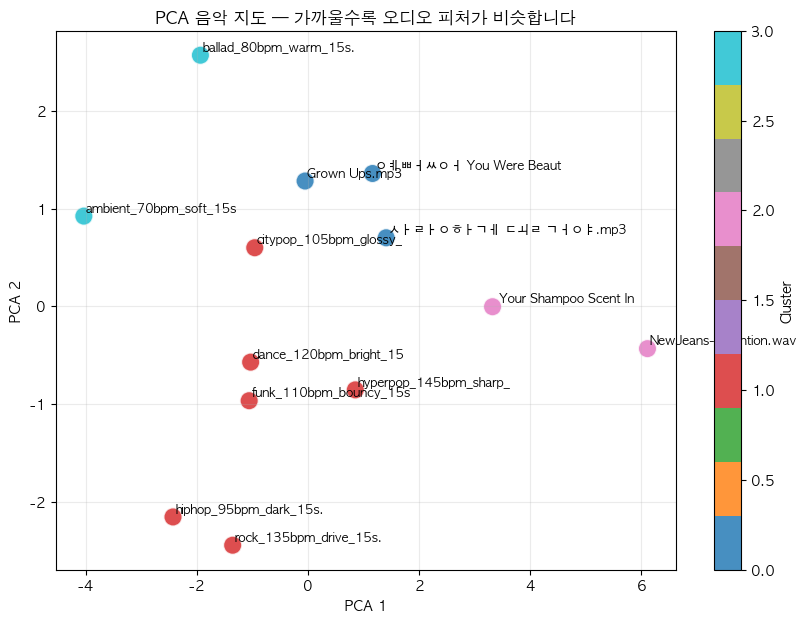

In [7]:
# [Step 3] 2D 음악 지도를 그립니다.
if {"cluster", "pca_x", "pca_y"}.issubset(cluster_df.columns):
    fig, ax = plt.subplots(figsize=(10, 7))
    scatter = ax.scatter(
        cluster_df["pca_x"],
        cluster_df["pca_y"],
        c=cluster_df["cluster"],
        cmap="tab10",
        s=180,
        alpha=0.82,
        edgecolor="white",
        linewidth=1.2,
    )
    for _, row in cluster_df.iterrows():
        ax.text(row["pca_x"] + 0.04, row["pca_y"] + 0.04, row["file"][:22], fontsize=9)
    ax.set_title("PCA 음악 지도 — 가까울수록 오디오 피처가 비슷합니다")
    ax.set_xlabel("PCA 1")
    ax.set_ylabel("PCA 2")
    ax.grid(alpha=0.25)
    plt.colorbar(scatter, ax=ax, label="Cluster")
    plt.show()

In [8]:
# [Step 4] 클러스터별 평균을 보고 이름을 붙여봅니다.
if "cluster" in cluster_df.columns:
    # mfcc_1(음색을 요약하는 대표 축 하나)을 추가해, "이 클러스터가 왜 갈렸는지"를
    # bpm/rms/centroid/zcr만으로 설명이 안 될 때 참고할 수 있게 합니다.
    profile = cluster_df.groupby("cluster")[["bpm", "rms", "centroid", "zcr", "mfcc_1"]].mean().round(3)
    display(profile)

    for cluster_id, group in cluster_df.groupby("cluster"):
        files = ", ".join(group["file"].head(5))
        print(f"Cluster {cluster_id}: {files}")

,bpm,rms,centroid,zcr,mfcc_1
cluster,,,,,
0,127.335,0.104,1525.879,0.055,-233.950
1,102.278,0.136,1157.463,0.035,-328.842
2,101.372,0.235,2193.468,0.083,-82.304
3,128.601,0.183,519.207,0.026,-378.434


Cluster 0: Grown Ups.mp3, 사랑하게 될 거야.mp3, 예뻤어 You Were Beautiful.mp3
Cluster 1: citypop_105bpm_glossy_15s.wav, dance_120bpm_bright_15s.wav, funk_110bpm_bouncy_15s.wav, hiphop_95bpm_dark_15s.wav, hyperpop_145bpm_sharp_15s.wav
Cluster 2:  Your Shampoo Scent In The Flowers.mp3, NewJeans-Attention.wav
Cluster 3: ambient_70bpm_soft_15s.wav, ballad_80bpm_warm_15s.wav


In [9]:
# [계약 검증] "오늘의 계약" 5번 — 클러스터 개수가 n_clusters를 넘지 않는지 실제로 확인합니다.
if "cluster" in cluster_df.columns:
    actual_clusters = cluster_df["cluster"].nunique()
    assert actual_clusters <= n_clusters, (
        f"클러스터 개수 이상: 실제 {actual_clusters}개가 n_clusters={n_clusters}개보다 많습니다"
    )
    print(f"[검증 통과] 실제 클러스터 개수 {actual_clusters}개 <= n_clusters {n_clusters}개")
else:
    print("[검증 생략] 샘플이 3개 미만이라 클러스터링을 건너뛰었습니다 (계약 3번 규칙).")

[검증 통과] 실제 클러스터 개수 4개 <= n_clusters 4개


### 🔎 관찰 포인트 — 방금 뽑은 BPM, 믿을 수 있을까?

Step 1에서 만든 표(`cluster_df`)를 다시 보면 이상한 값들이 보입니다.

| 파일명 | 실제 BPM(파일명 표기) | 추정된 BPM |
|---|---|---|
| `ballad_80bpm_warm_15s.wav` | 80 | **161.5** |
| `hyperpop_145bpm_sharp_15s.wav` | 145 | **95.7** |
| `rock_135bpm_drive_15s.wav` | 135 | **89.1** |

세 곡 모두 실제 BPM의 정확히 절반 또는 두 배 근처로 잘못 추정됐습니다 — 이를 **템포 옥타브 에러(tempo octave error)**라고 부릅니다. 온셋(onset) 검출 기반 템포 추정 알고리즘은 "두 배 빠르기"와 "절반 빠르기"를 구분하기 어려워하는 알려진 한계가 있습니다(예: 느린 곡에서 스네어의 세부 간격을 곡 전체 박자로 착각). 이는 코드 버그가 아니라 **오디오 신호 처리 도구 자체의 현실적 한계**이며, 이런 값이 클러스터링 결과에 섞여 있을 수 있다는 것을 알고 결과를 해석해야 합니다.

### 💡 profile 표 직접 읽어보기 — 이름 붙이기 시연

방금 나온 `profile` 표에서 **Cluster 2**를 봅시다: `rms 0.235 · centroid 2193`. rms(에너지)가 4개 클러스터 중 가장 크고, centroid(밝기)도 가장 높습니다 — 즉 "에너지가 크고 음색이 밝은" 곡들이 모였다는 뜻이므로, 저라면 이 클러스터에 **"청량 팝"**이라는 이름을 붙이겠습니다. 이렇게 표의 숫자 하나하나를 "이 곡이 왜 여기 묶였는가"에 대한 근거로 읽는 것이 클러스터링 해석의 핵심입니다. 나머지 클러스터도 같은 방식으로 직접 이름을 붙여보세요.


### 결과 해석 — "실행 전 예측"과 비교해보기

- 클러스터 번호는 정답 라벨이 아니라 "비슷한 피처끼리 묶은 임시 이름"입니다.
- 여러분이 직접 클러스터 이름을 붙이면 분석이 훨씬 살아납니다. 예: 운동용, 새벽 감성, 청량 팝, 어두운 비트.
- 앞서 "실행 전 예측"에서 어떤 곡들이 묶일지 미리 적어봤습니다 — 방금 그린 PCA 지도·클러스터별 평균(`profile`)과 비교했을 때, 예상과 맞았나요? 틀렸다면 어떤 피처가 예상과 다르게 작동했을까요? (예: BPM은 비슷한데 mfcc 음색이 크게 달라서 다른 클러스터로 갈렸을 수 있습니다.)
- 4강에서는 이 곡들을 이미지처럼 바꿔서 딥러닝 입력으로 살펴봅니다.

> 🎲 **불확실성 참고**: KMeans는 초기 중심점을 무작위로 놓고 시작하지만, 이 노트북은 `random_state=42`로 고정했으므로 같은 데이터·같은 컴퓨터에서는 클러스터 번호(0,1,2,3)와 그룹 구성이 항상 동일하게 재현됩니다. 다만 **오디오 파일 목록 자체**는 `latest_music_local` 폴더에 무엇을 넣어뒀는지에 따라 사람마다 다르므로, 다른 컴퓨터에서 실행하면 지도의 모양 자체가 달라질 수 있습니다 — 이는 버그가 아니라 "내 플레이리스트로 내 지도를 그린다"는 이 노트북의 설계 의도입니다.

> 🤖 **AI Agent에서 이렇게 씁니다**: 지금 한 일 — "곡을 숫자 벡터로 바꾸고, 벡터가 가까운 것끼리 묶는다" — 는 뒤에서 만들 Voice RAG 에이전트가 쓰는 벡터 검색(vector search)과 원리가 완전히 같습니다. 그때는 가사·메타데이터를 텍스트 임베딩 벡터로 바꾸고, 벡터DB가 "질문 벡터와 가까운 문서 벡터"를 찾아 답을 만듭니다. 지금 11차원 오디오 피처 공간에서 KMeans가 하는 일이, 나중엔 수백 차원 임베딩 공간에서의 유사도 검색으로 규모만 커지는 것입니다.

---
## 🤝 AI Pair 섹션 — 플레이리스트 클러스터링

> **목표**: AI를 답 베끼는 도구가 아니라 *내 코드·판단을 검증해주는 동료*로 쓴다. (읽기용 — 실습 시간엔 핵심만 따라가도 됩니다)

| 단계 | 내가 하는 것 | AI가 하는 것 |
|---|---|---|
| 1️⃣ Solo | 먼저 직접 작성/판단 | (아직 X) |
| 2️⃣ Review | 내 코드·판단을 제출 | 리뷰 + 근거 설명 |
| 3️⃣ Debug | AI가 준 "조용히 틀린" 코드의 결함 찾기 | 의도적 버그 제공 |
| 4️⃣ Prompt Card | 실험 설계 프롬프트 익히기 | — |

### 1️⃣ Solo — 먼저 스스로 풀어보세요
💡 *AI에게 물으면 30초 만에 답이 나오지만, 지금 막히는 지점이 이 강의 핵심입니다.*

### ✏️ [Solo 레벨 1] 직접 작성해 보세요 — n_clusters를 2로 바꾸기

힌트: [Step 2] 셀을 그대로 복사해서 n_clusters = min(4, len(cluster_df)) → n_clusters = min(2, len(cluster_df))만 바꿔보세요.

요구사항 (여기까지 해야 완료입니다):
1) K=2로 클러스터링을 다시 돌려 profile 표(bpm/rms/centroid/zcr 평균)를 만드세요.
2) 원래 K=4일 때의 profile 표([Step 4] 셀의 결과)와 나란히 비교하세요.
3) 아래 형태의 표를 직접 채워(마크다운이든 print든 상관없습니다) 결론을 적으세요.

| K | 클러스터 수 | 이름 붙이기 난이도(쉬움/보통/어려움) | 이유 |
|---|---|---|---|
| 2 | 2 |  |  |
| 4 | 4 |  |  |

4) 마지막 줄에 한 문장으로 결론을 쓰세요: "K=___일 때가 이름 붙이기 더 쉬웠다. 왜냐하면 ___."

In [10]:
n_clusters_lv1 = min(2, len(cluster_df))
# TODO: 여기에 작성하세요 -- [Step 2] 셀의 X, kmeans, cluster_df 로직을 그대로 가져와
#       n_clusters 자리에 n_clusters_lv1을 넣고 다시 클러스터링한 뒤,
#       [Step 4] 셀처럼 groupby("cluster")[["bpm", "rms", "centroid", "zcr"]].mean()으로 K=2 profile 표를 만드세요.


### 🔍 Solo 레벨 2 준비 — `librosa.effects.harmonic`이 실제로 무엇을 돌려주는지 확인
섹션 2(코드를 읽기 전에)에서 '하모닉 성분'을 말로 설명했습니다 — 음정이 뚜렷한 성분과 타악기성 성분을 분리하는 `librosa.effects.harmonic(y)`입니다. 레벨 2를 풀기 전에, 이 함수가 실제로 무엇을 돌려주는지 한 곡에 직접 찍어봅니다.


### ✏️ [Solo 레벨 2 준비 — 확인해보기] librosa.effects.harmonic이 돌려주는 값을 직접 확인합니다.

여기서는 계산 방법(레시피)만 보여줍니다 — harmonic_ratio를 cluster_df에 추가하는 것은 레벨 2에서 직접 하세요.

In [ ]:
demo_path = audio_files[0]
y_demo, sr_demo = librosa.load(demo_path, sr=SAMPLE_RATE, mono=True, duration=10.0)
y_harmonic_demo = librosa.effects.harmonic(y_demo)

print(f"파일: {demo_path.name}")
print(f"원본 y.shape        = {y_demo.shape}")
print(f"하모닉 성분 shape    = {y_harmonic_demo.shape}  (원본과 길이가 같습니다 — 파형에서 '음정 있는 부분'만 남긴 것)")
print(f"원본 RMS 평균        = {np.mean(librosa.feature.rms(y=y_demo)[0]):.4f}")
print(f"하모닉 성분 RMS 평균  = {np.mean(librosa.feature.rms(y=y_harmonic_demo)[0]):.4f}")
print()
print("[관찰] y_harmonic_demo도 y_demo와 동일하게 librosa.feature.rms(y=...)에 그대로 넣을 수 있습니다 —")
print("       두 RMS 값을 어떻게 조합하면 '이 곡이 얼마나 하모닉한가'를 나타내는 비율 하나가 될지 레벨 2에서 직접 설계해보세요.")


### ✏️ [Solo 레벨 2] 직접 작성해 보세요 — 새로운 피처(harmonic ratio) 추가하기

힌트: librosa.effects.harmonic(y)로 하모닉 성분을 뽑고, 원본 y 대비 에너지 비율(RMS)을 새 피처로 추가하세요.
extract_cluster_features 함수를 복사해서 harmonic_ratio 키를 하나 더 반환하도록 고치고, 다시 클러스터링해보세요.

In [11]:
def extract_cluster_features_v2(path):
    # TODO: 여기에 작성하세요 (extract_cluster_features를 참고해 harmonic_ratio 피처를 추가)
    pass


### 🔍 Solo 레벨 3 준비 — `kmeans.inertia_`, 실제 값으로 확인
섹션 2에서 inertia_가 무엇인지 설명했습니다 — 지금 K=4로 학습된 `kmeans` 객체([Step 2] 결과)의 실제 inertia_ 값을 확인해봅니다.


### ✏️ [Solo 레벨 3 준비 — 확인해보기] 방금 [Step 2]에서 학습한 kmeans(K=4)의 inertia_를 직접 찍어봅니다.


In [ ]:
if "kmeans" in globals():
    print(f"K={n_clusters}일 때 kmeans.inertia_ = {kmeans.inertia_:.2f}")
    print("[관찰] fit_predict를 호출한 뒤에는 kmeans.inertia_ 속성으로 바로 읽을 수 있습니다.")
    print("       레벨 3에서는 이 값을 K=2~6 각각에 대해 반복 계산해 리스트로 모아야 합니다.")
else:
    print("[안내] 먼저 [Step 2] 셀을 실행해 kmeans를 만들어야 합니다.")


### ✏️ [Solo 레벨 3] 직접 작성해 보세요 — Elbow Method로 적절한 K 찾기

힌트:
1) K를 2~6까지 바꿔가며 KMeans(n_clusters=K, random_state=42, n_init=10)로 학습하세요.
2) 각 K에서 kmeans.inertia_(클러스터 내 분산의 합)를 리스트에 저장하세요.
3) matplotlib으로 x=K, y=inertia 그래프를 그려 "팔꿈치"가 꺾이는 지점을 눈으로 찾아보세요.
(완만해지기 시작하는 지점이 데이터가 실제로 원하는 클러스터 개수에 가깝습니다.)

In [12]:
def find_elbow(X, k_range=range(2, 7)):
    # TODO: 여기에 작성하세요
    pass


### 2️⃣ Review
아래 프롬프트를 복사해 ChatGPT/Claude에 붙여넣으세요.
```text
곡별 오디오 피처(bpm, rms, centroid, rolloff, zcr, flatness, mfcc_1~5) 11개를 StandardScaler로 정규화한 뒤 KMeans(n_clusters=4)로 클러스터링하고 PCA로 2D 시각화했습니다.
1) 왜 스케일링을 KMeans보다 먼저 해야 하는지, 2) PCA 2D 지도에서 가까운 두 점이 반드시 "같은 클러스터"는 아닐 수 있는 이유, 3) 샘플 수가 10개 미만으로 적을 때 KMeans 결과를 얼마나 신뢰할 수 있는지 각각 근거를 들어 설명해줘.
```

In [13]:
# ── 2️⃣ Review (코드형) — 로컬/클라우드 LLM에게 내 코드·판단을 리뷰받기 ──
# [사전조건] 로컬: LM Studio(00-1)/Ollama(00-2) 서버 실행  |  클라우드: OPENROUTER/OPENAI 키 설정
# openai 패키지가 없으면 아래 주석을 풀어 한 번만 실행하세요 (이미 있으면 건너뛰기)
# !pip install openai
import os
try:
    from openai import OpenAI
except ImportError:
    OpenAI = None

if OpenAI is None:
    print("[안내] openai 패키지가 없어 이 Review 셀을 건너뜁니다 — `!pip install openai` 후 다시 실행하세요(선택 사항입니다).")
else:
    PROVIDER = "lmstudio"   # "lmstudio" | "ollama" | "openrouter" | "openai"  ← 한 줄만 바꾸면 전환
    PROVIDERS = {
        "lmstudio":   {"base_url": "http://localhost:1234/v1",  "model": "local-model",          "api_key": "lm-studio"},
        "ollama":     {"base_url": "http://localhost:11434/v1", "model": "llama3.2",             "api_key": "ollama"},
        "openrouter": {"base_url": "https://openrouter.ai/api/v1", "model": "openai/gpt-4o-mini", "api_key": os.getenv("OPENROUTER_API_KEY", "")},
        "openai":     {"base_url": "https://api.openai.com/v1", "model": "gpt-4o-mini",           "api_key": os.getenv("OPENAI_API_KEY", "")},
    }
    cfg = PROVIDERS[PROVIDER]
    client = OpenAI(base_url=cfg["base_url"], api_key=cfg["api_key"])

    review_prompt = '''
    곡별 오디오 피처(bpm, rms, centroid, rolloff, zcr, flatness, mfcc_1~5) 11개를 StandardScaler로 정규화한 뒤
    KMeans(n_clusters=4)로 클러스터링하고 PCA로 2D 시각화했습니다.
    1) 왜 스케일링을 KMeans보다 먼저 해야 하는지,
    2) PCA 2D 지도에서 가까운 두 점이 반드시 "같은 클러스터"는 아닐 수 있는 이유,
    3) 샘플 수가 10개 미만으로 적을 때 KMeans 결과를 얼마나 신뢰할 수 있는지
    각각 근거를 들어 설명해줘.
    '''

    try:
        resp = client.chat.completions.create(
            model=cfg["model"],
            messages=[{"role": "user", "content": review_prompt}],
            temperature=0.3,
        )
        print(resp.choices[0].message.content)
    except Exception as exc:
        print(f"[안내] LLM 서버에 연결할 수 없습니다: {exc}")
        print("로컬 서버(LM Studio/Ollama)를 켜거나 PROVIDER를 openrouter/openai로 바꾸고 API 키를 설정하세요.")

[안내] LLM 서버에 연결할 수 없습니다: Connection error.
로컬 서버(LM Studio/Ollama)를 켜거나 PROVIDER를 openrouter/openai로 바꾸고 API 키를 설정하세요.


### 3️⃣ Debug — "조용히 틀린" 코드 찾기
아래는 **실행은 되고 에러도 안 나지만, 조용히 잘못된 결과를 내는** 코드입니다. 결함을 찾아 고치세요.

In [14]:
# [Debug] 아래 코드는 에러 없이 실행됩니다 — 그런데 스케일링을 빼먹었습니다. 결함을 찾아 고쳐보세요.
from sklearn.cluster import KMeans as _KMeans
from sklearn.decomposition import PCA as _PCA

feature_cols_bug = [c for c in cluster_df.columns if c not in ("file", "cluster", "pca_x", "pca_y")]

if len(cluster_df) >= 3:
    # ⚠️ 여기를 의심해보세요 — StandardScaler 없이 원본 피처를 그대로 사용합니다
    X_bug = cluster_df[feature_cols_bug].values
    n_clusters_bug = min(4, len(cluster_df))
    kmeans_bug = _KMeans(n_clusters=n_clusters_bug, random_state=42, n_init=10)
    cluster_bug = kmeans_bug.fit_predict(X_bug)
    print("버그 버전 클러스터 배정:", cluster_bug)
    print("정상 버전(cluster 컬럼)  :", cluster_df["cluster"].tolist() if "cluster" in cluster_df.columns else "먼저 [Step 2] 셀을 실행하세요")

버그 버전 클러스터 배정: [0 1 0 3 3 2 2 1 1 1 1 3 1]
정상 버전(cluster 컬럼)  : [2, 0, 2, 0, 0, 3, 3, 1, 1, 1, 1, 1, 1]


💭 **생각해 볼 점**:
- 이 코드는 에러 없이 "실행"됩니다. 왜 에러가 안 날까요? (KMeans는 스케일이 다른 숫자 배열도 그냥 거리로 계산하기 때문입니다 — shape만 맞으면 됩니다.)
- `centroid`(수백~수천 Hz)와 `rms`(0~1)를 스케일링 없이 그대로 유클리드 거리로 계산하면, 사실상 어떤 피처 하나가 클러스터링 결과를 "혼자" 결정하게 됩니다. 어떤 피처가 그럴 가능성이 가장 높을까요?
- 버그 버전과 정상 버전(`cluster` 컬럼)의 클러스터 배정을 비교해보세요 — 완전히 같다면 두 배열의 순서만 다를 수도 있으니, `profile`(클러스터별 평균) 값의 스케일 자체를 비교하는 게 더 확실합니다.

### 4️⃣ Prompt Card
📝 **카드 1~3** (이 단원 최적화, 실험 설계형):
```text
1. "n_clusters를 2에서 8까지 바꿔가며 KMeans의 inertia_ 값을 비교해서 Elbow 그래프를 그려주고, 몇 개가 적절해 보이는지 근거와 함께 알려줘."
2. "mfcc 계수 개수를 5개에서 13개로 늘리면 클러스터링 결과가 어떻게 달라질지 먼저 예측한 뒤 AI에게 이유를 물어봐줘."
3. "StandardScaler 대신 MinMaxScaler를 쓰면 클러스터 결과가 달라질지 AI와 같이 예측하고 실행해서 확인해줘."
```
🎯 **마무리 체크**: [ ] Solo 직접 [ ] Review 실행검증 [ ] Debug 결함 찾음 [ ] Prompt Card 1개 내 노트에 정리

---
## 📚 [세션 요약] 플레이리스트 클러스터링

> 🎯 **핵심 Takeaways**
> 1. **이론적 근거**: 정답 라벨 없이도 StandardScaler + KMeans + PCA만으로 "비슷한 곡" 그룹을 자동으로 찾을 수 있다 — 이것이 비지도학습의 힘.
> 2. **실무적 활용**: 스케일링을 빼먹으면 코드는 돌아가지만 결과가 조용히 틀려진다 — 에러 없음이 정답의 증거는 아니다.
>
> ➡️ **다음 단계**: `4강_소리를이미지로_멜스펙트로그램(AI_Pair).ipynb` — 소리를 이미지처럼 바꿔 CNN 입력을 준비합니다.